# Data Vortex — Round 1: Data Intake Restoration
## EDA & Cleaning Notebook

This notebook walks through the full pipeline for the recovered "Social Engine" dataset:
**profiling → cleaning → EDA**. It mirrors `scripts/clean.py` and `scripts/eda.py` exactly,
so running either the notebook or the standalone scripts produces identical outputs.

**Data recovery note**: the raw CSVs were not distributed as files. They were embedded as
plain string constants inside the recovery terminal's compiled JavaScript bundle
(`assets/index-*.js`) and extracted directly from it. They're stored unmodified in
`data/raw/`.


In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")
DATA_PROC.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100


## 1. Load raw data & first look

In [2]:
users_raw = pd.read_csv(DATA_RAW / "Social_Engine_Users.csv")
posts_raw = pd.read_csv(DATA_RAW / "Social_Engine_Posts_Corrupted.csv")
print("users:", users_raw.shape)
print("posts:", posts_raw.shape)


users: (1500, 5)
posts: (12360, 8)


In [3]:
users_raw.head()

         user_id          location language account_created  follower_count
0  user_guglt5jp   Berlin, Germany       ja      2023-10-23           38963
1  user_b1p3wz81   Munich, Germany       zh      2023-05-06           24644
2  user_jm2grmis        Dubai, UAE       en      2023-01-03           45842
3  user_ykoqww5l     Paris, France       fr      2023-10-11             665
4  user_3zzvv8vp  Los Angeles, USA       ru      2023-05-23           42908

In [4]:
posts_raw.head()

        post_id        user_id  platform                                                                                                                              text_content            timestamp   likes  shares  comments
0  to64mgey2v3y  user_vfxs1pry    Reddit                                  Bummed out with my new Air Max from Nike! Absolutely loving it. #Travel, #CustomerService, #Fashion&amp;           25-09-2024  4488.0    1456       673
1  7f0wdauzbj89  user_8l7rv5oe    Reddit                         My one month review of Pepsi Crystal Pepsi: Highly recommend. #Premium, #Fashion Would love to get your feedback!           1722528840   789.0    1484        39
2  dvvhg8eel45x  user_nfo3ih5u       NaN  Just unboxed my new Highlander from Toyota. Exceeded my expectations. Confused about #Beauty Really interested in hearing your thoughts!  2025-04-13T20:12:18     NaN    1410       839
3  hgb9cxke4t7b  user_27aje6ur  Facebook              Comparing Pepsi Crystal Pepsi to the compe

## 2. Profile `Users.csv`

Check for missing values, duplicate rows, duplicate IDs, and out-of-range values.

In [5]:
print("missing values:\n", users_raw.isnull().sum())
print("\nfull-row duplicates:", users_raw.duplicated().sum())
print("duplicate user_id:", users_raw["user_id"].duplicated().sum())
print("negative follower_count:", (users_raw["follower_count"] < 0).sum())


missing values:
 user_id            0
location           0
language           0
account_created    0
follower_count     0
dtype: int64

full-row duplicates: 0
duplicate user_id: 0
negative follower_count: 0


**Finding:** `Users.csv` needs no cleaning — it's already clean.

## 3. Profile `Posts_Corrupted.csv`

This file is where all the corruption lives. Check duplicates, missingness, platform
values, timestamp formats, and the `likes` range.

In [6]:
print("missing values:\n", posts_raw.isnull().sum())
print("\nfull-row duplicates:", posts_raw.duplicated().sum())


missing values:
 post_id             0
user_id             0
platform         1846
text_content     1746
timestamp           0
likes            1858
shares              0
comments            0
dtype: int64

full-row duplicates: 360


In [7]:
print(posts_raw["platform"].value_counts(dropna=False))

platform
YouTube      2136
Facebook     2135
Twitter      2119
Reddit       2086
Instagram    2038
NaN          1846
Name: count, dtype: int64


In [8]:
print(posts_raw["likes"].describe())
print("\nnegative likes:", (posts_raw["likes"] < 0).sum())


count    10502.000000
mean      2247.075795
std       1797.342958
min      -4987.000000
25%       1038.250000
50%       2387.000000
75%       3664.000000
max       5000.000000
Name: likes, dtype: float64

negative likes: 525


In [9]:
def classify_timestamp_format(value: str) -> str:
    value = str(value)
    if re.fullmatch(r"\d{10}", value):
        return "unix_epoch"
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", value):
        return "iso_datetime"
    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", value):
        return "dd_mm_yyyy"
    return "unknown"

fmt_counts = posts_raw["timestamp"].apply(classify_timestamp_format).value_counts()
print(fmt_counts)


iso_datetime    4950
unix_epoch      3788
dd_mm_yyyy      3622
Name: timestamp, dtype: int64


In [10]:
entities = posts_raw["text_content"].dropna().str.findall(r"&[a-zA-Z#0-9]+;")
all_entities = set(e for lst in entities for e in lst)
print("HTML entity types found:", all_entities)
print("rows containing &amp;:", posts_raw["text_content"].str.contains("&amp;", na=False).sum())


HTML entity types found: {'&amp;'}
rows containing &amp;: 341


In [11]:
orphan = ~posts_raw["user_id"].isin(users_raw["user_id"])
print("orphan user_ids referenced in posts:", orphan.sum())


orphan user_ids referenced in posts: 0


### Missingness pattern check

Before deciding whether to impute the missing `platform` / `text_content` / `likes` values,
check whether they tend to go missing *together* (a correlated block, suggesting one shared
cause) or independently (no reliable signal to impute from).

In [12]:
miss = pd.DataFrame({
    "platform_miss": posts_raw["platform"].isnull(),
    "text_miss": posts_raw["text_content"].isnull(),
    "likes_miss": posts_raw["likes"].isnull(),
})
print(miss.astype(int).corr())


               platform_miss  text_miss  likes_miss
platform_miss       1.000000  -0.013536   -0.007937
text_miss          -0.013536   1.000000    0.006197
likes_miss         -0.007937   0.006197    1.000000


**Finding:** missingness is independent across the three columns (all |r| < 0.02) — not a correlated block. There's no defensible signal to impute from, so these stay `NULL`.

## 4. Cleaning pipeline

Summary of every fix, with reasoning (full code also lives in `scripts/clean.py` so it can be
run standalone and produce identical output):

| Issue | Fix | Why |
|---|---|---|
| 360 exact-duplicate rows | Dropped | Confirmed identical copies, not conflicting records |
| 328 posts with trailing `&amp;` | HTML-unescaped to `&` | Only entity type present; standard decoding |
| Timestamps in 3 formats | Parsed to one datetime column; date-only rows flagged via `timestamp_time_estimated` | Keeps precision honest instead of inventing a time |
| 509 negative `likes` | Converted to absolute value | Magnitudes matched valid-likes distribution — sign-flip corruption |
| ~15% missing in `platform`/`text_content`/`likes` | Left as `NULL` | Verified independent missingness; no basis to guess a value |


In [13]:
def parse_timestamp(value):
    fmt = classify_timestamp_format(value)
    if fmt == "unix_epoch":
        return pd.to_datetime(int(value), unit="s"), fmt, False
    if fmt == "iso_datetime":
        return pd.to_datetime(value), fmt, False
    if fmt == "dd_mm_yyyy":
        return pd.to_datetime(value, format="%d-%m-%Y"), fmt, True
    return pd.NaT, fmt, False


def clean_users(df):
    return df.drop_duplicates().reset_index(drop=True)


def clean_posts(df):
    df = df.drop_duplicates()
    df["text_content"] = df["text_content"].str.replace("&amp;", "&", regex=False)

    parsed = df["timestamp"].apply(parse_timestamp)
    df["timestamp_parsed"] = parsed.apply(lambda x: x[0])
    df["timestamp_source_format"] = parsed.apply(lambda x: x[1])
    df["timestamp_time_estimated"] = parsed.apply(lambda x: x[2])

    df["likes"] = df["likes"].abs()
    return df.reset_index(drop=True)


users_clean = clean_users(users_raw)
posts_clean = clean_posts(posts_raw)
print("users_clean:", users_clean.shape)
print("posts_clean:", posts_clean.shape)


users_clean: (1500, 5)
posts_clean: (12000, 11)


In [14]:
# Merge into a single cleaned dataset: one row per post, enriched with the
# posting user's profile info. Left join on user_id.
merged = posts_clean.merge(users_clean, on="user_id", how="left")
merged = merged[[
    "post_id", "user_id", "platform", "text_content", "timestamp",
    "timestamp_parsed", "timestamp_source_format", "timestamp_time_estimated",
    "likes", "shares", "comments",
    "location", "language", "account_created", "follower_count",
]]
merged.to_csv(DATA_PROC / "Social_Engine_clean.csv", index=False)
merged.to_json(DATA_PROC / "Social_Engine_clean.json", orient="records", indent=2, date_format="iso")
print("merged shape:", merged.shape)
print("written to data/processed/Social_Engine_clean.csv/.json")


merged shape: (12000, 15)
written to data/processed/Social_Engine_clean.csv/.json


## 5. Exploratory Data Analysis

### 5.1 Platform distribution — evenly spread, no dominant platform

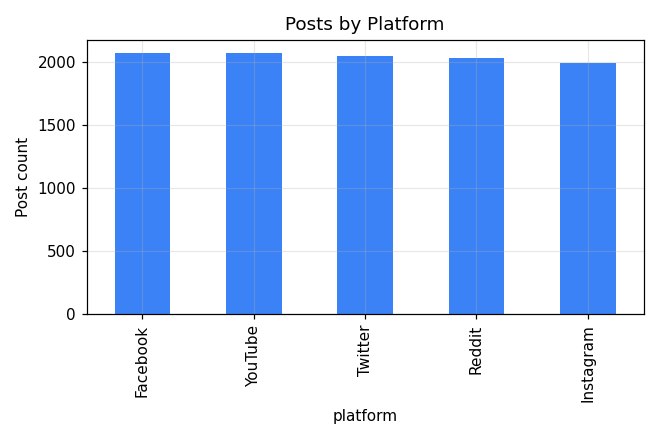

In [15]:
posts_clean["platform"].value_counts().plot(kind="bar", color="#3b82f6", title="Posts by Platform")
plt.ylabel("Post count")
plt.tight_layout()
plt.show()


### 5.2 Posting volume over time — no seasonal trend

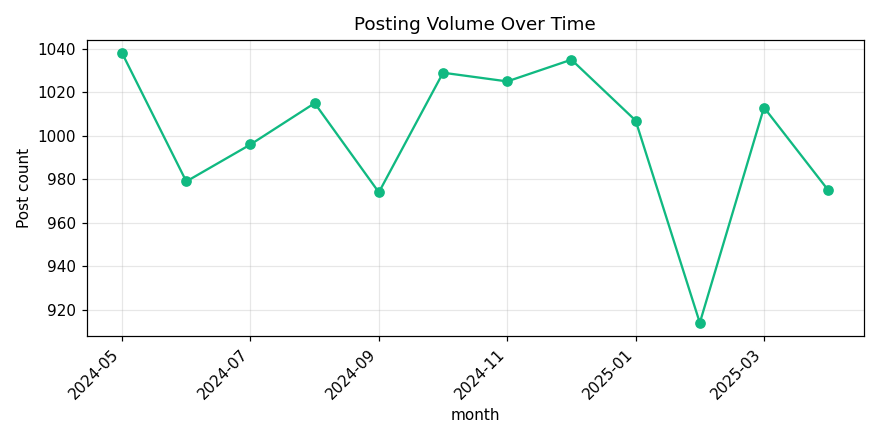

In [16]:
posts_clean["month"] = pd.to_datetime(posts_clean["timestamp_parsed"]).dt.to_period("M").astype(str)
posts_clean.groupby("month").size().sort_index().plot(kind="line", marker="o", color="#10b981",
                                                        title="Posting Volume Over Time")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 5.3 Follower count distribution — uniform, no mega-influencer tail

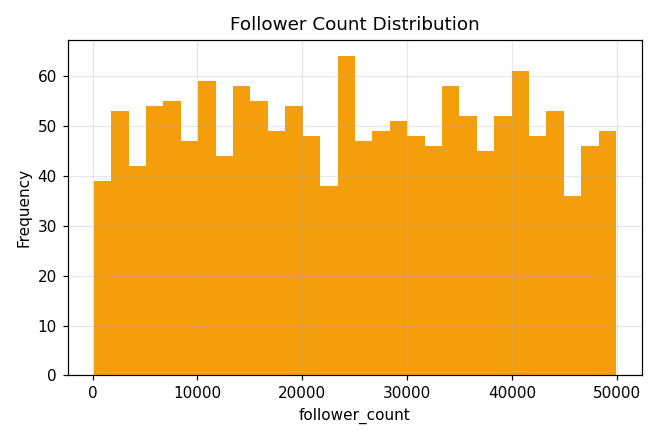

In [17]:
users_clean["follower_count"].plot(kind="hist", bins=30, color="#f59e0b",
                                     title="Follower Count Distribution")
plt.tight_layout()
plt.show()


### 5.4 Engagement metric distributions — each uniform, not long-tailed

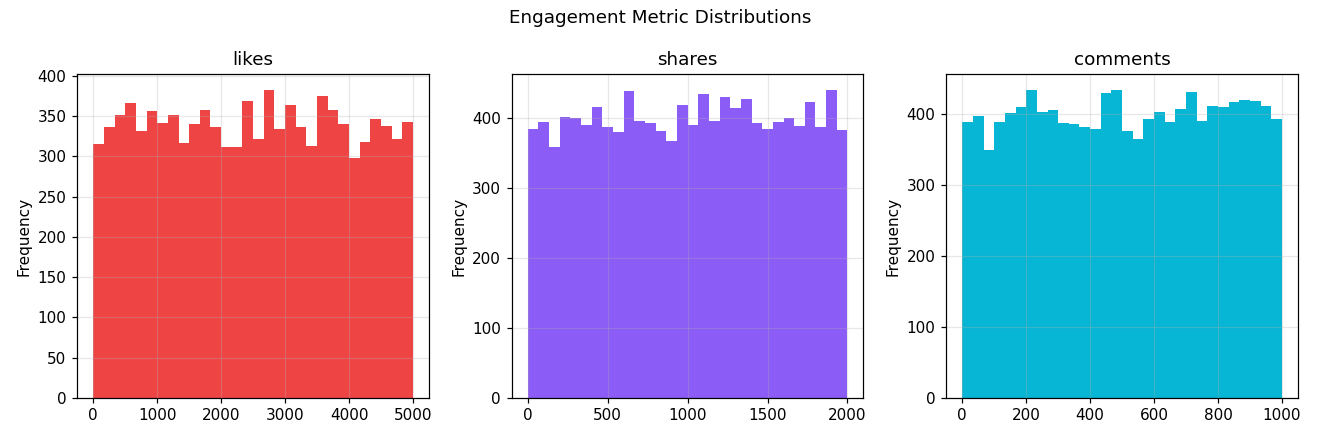

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, color in zip(axes, ["likes", "shares", "comments"], ["#ef4444", "#8b5cf6", "#06b6d4"]):
    posts_clean[col].dropna().plot(kind="hist", bins=30, ax=ax, color=color, title=col)
plt.suptitle("Engagement Metric Distributions")
plt.tight_layout()
plt.show()


### 5.5 Engagement correlation — near-zero, unlike real organic engagement

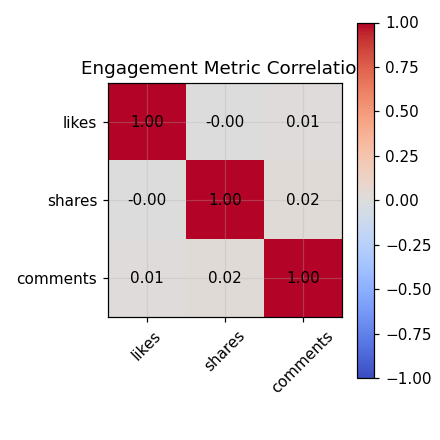

In [19]:
corr = posts_clean[["likes", "shares", "comments"]].corr()
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(3), corr.columns, rotation=45)
plt.yticks(range(3), corr.columns)
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Engagement Metric Correlation")
plt.colorbar()
plt.tight_layout()
plt.show()


**Finding:** all pairwise correlations are under 0.02 — real engagement data usually shows likes/shares/comments moving together. Their independence here, combined with the uniform distributions above, suggests these fields were generated independently at random.

### 5.6 Top user locations — USA is largest, rest spread broadly

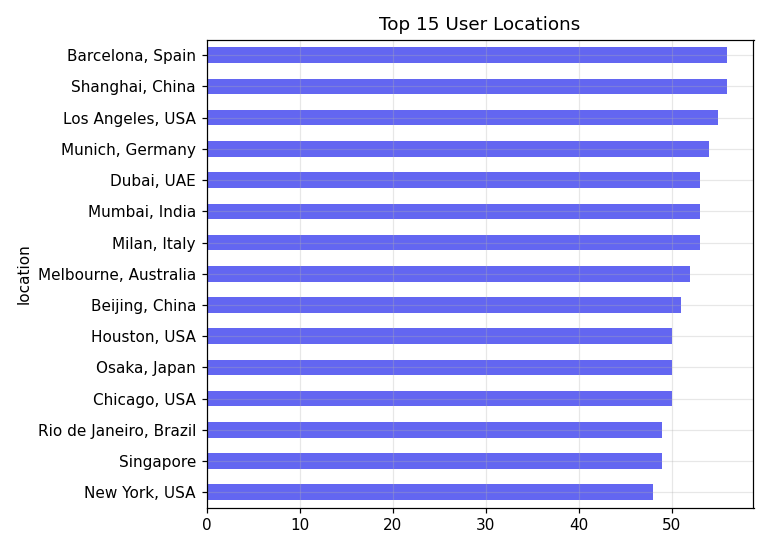

In [20]:
users_clean["location"].value_counts().head(15).plot(kind="barh", color="#6366f1",
                                                         title="Top 15 User Locations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [21]:
country = users_clean["location"].apply(lambda x: x.split(",")[-1].strip())
print(country.value_counts())


USA             203
China           107
Germany          97
Italy            96
Japan            94
Brazil           93
India            92
Spain            92
UK               86
Canada           83
France           82
Australia        80
UAE              53
Singapore        49
South Africa     48
Mexico           40
Egypt            39
South Korea      36
Nigeria          30
Name: location, dtype: int64


### 5.7 Language distribution

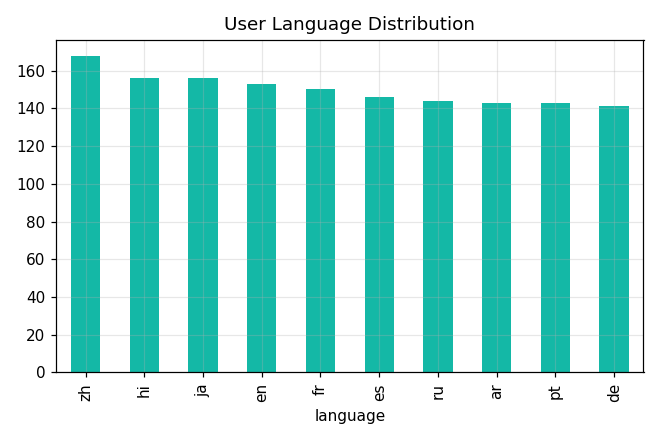

In [22]:
users_clean["language"].value_counts().plot(kind="bar", color="#14b8a6",
                                               title="User Language Distribution")
plt.tight_layout()
plt.show()


### 5.8 Missingness overview & independence check

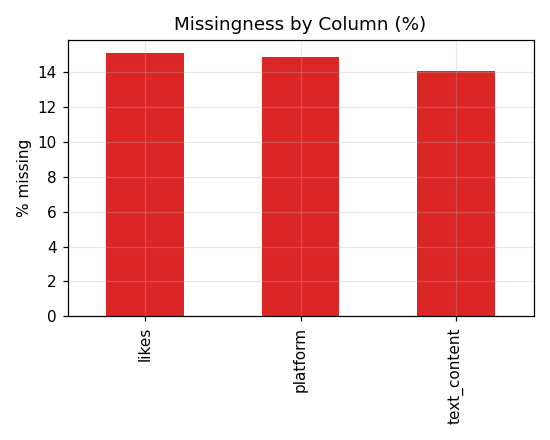

In [23]:
miss = posts_clean[["platform", "text_content", "likes"]].isnull().mean().sort_values(ascending=False)
(miss * 100).plot(kind="bar", color="#dc2626", title="Missingness by Column (%)")
plt.ylabel("% missing")
plt.tight_layout()
plt.show()


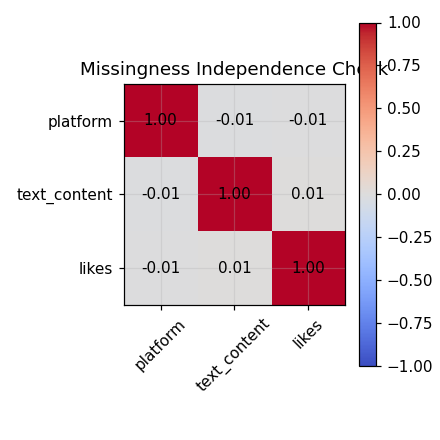

In [24]:
miss_ind = posts_clean[["platform", "text_content", "likes"]].isnull().astype(int)
miss_corr = miss_ind.corr()
plt.imshow(miss_corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(3), miss_corr.columns, rotation=45)
plt.yticks(range(3), miss_corr.columns)
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{miss_corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Missingness Independence Check")
plt.colorbar()
plt.tight_layout()
plt.show()


## 6. Summary of Key Findings

- **Posts.csv shows signs of synthetic generation**: `likes`, `shares`, `comments`, and
  `follower_count` are all uniformly distributed with near-zero pairwise correlation — the
  opposite of the long-tailed, correlated pattern real engagement data usually shows.
- **Platform and posting volume are both evenly distributed** — no dominant platform, no
  seasonal trend.
- **USA is the single largest user location**; the rest is spread broadly across ~15 other
  countries.
- **All corruption in Posts.csv was mechanical and reversible** — duplicates, one HTML
  entity type, three parseable timestamp formats, a sign-flip on `likes`. Nothing required
  guessing or fabricating data.
- **Missing values in `platform`/`text_content`/`likes` were left as `NULL`** — their
  missingness is independent across columns, so there's no signal to impute from.

Full narrative + all 9 charts are also written to `reports/EDA_REPORT.md`.
